In [1]:
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing_extensions import TypedDict

c:\Users\aksha\OneDrive\Desktop\langgraph\langgraph\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
load_dotenv()

True

In [3]:
parent_llm = ChatGroq(model="qwen/qwen3.6-27b")
subgraph_llm = ChatGroq(model="qwen/qwen3.6-27b")

In [4]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str

In [5]:
def translate_text(state: ParentState):

    prompt = f"""
Translate the following text to Hindi.Keep it natural and clear. Do not add extra content.Text:{state["answer_eng"]}""".strip()
    translated_text = subgraph_llm.invoke(prompt).content
    return {'answer_hin': translated_text}


def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [6]:
#subgraph
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [7]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph) #added graph as a node

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

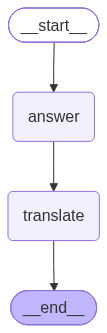

In [8]:
graph = parent_builder.compile()

graph

In [10]:
graph.invoke({'question': 'Write a poem on water'})

{'question': 'Write a poem on water',
 'answer_eng': '\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - **Task:** Write a poem\n   - **Topic:** Water\n   - **Tone/Style:** Not specified, so I\'ll aim for something evocative, versatile, and clearly structured\n   - **Constraint:** "Answer clearly" - keep it focused and well-crafted\n\n2.  **Brainstorming Core Themes/Imagery for Water:**\n   - States: liquid, ice, vapor, rain, ocean, river, dew, waves\n   - Qualities: fluid, adaptable, life-giving, relentless, reflective, deep, quiet yet powerful\n   - Metaphors: time, memory, journey, cleansing, persistence\n   - Structure: Maybe 4-5 stanzas, consistent meter/rhyme or free verse with strong rhythm. I\'ll go with a structured but flowing style (AABB or ABAB, or maybe consistent line length).\n\n3.  **Drafting - Stanza by Stanza (Mental Refinement):**\n   *Stanza 1: Origin/Stillness*\n   It begins in silence, deep and clear,\n   A hidden spring that whispers near